# Notebook 02 — Modelo-Base Autorregressivo (H=3 meses)

> **Objetivo:** Treinar e avaliar ARIMA, XGBoost e SVR para prever a inadimplência total com horizonte de **3 meses à frente**, usando apenas o histórico da própria série — sem variáveis exógenas macroeconômicas e sem sentimento.
>
> Este notebook serve como **baseline autorregressivo**: o ganho dos modelos de sentimento será avaliado no Notebook 06 pela comparação com estes resultados.
>
> **Critério de seleção de lags/ordem:** menor RMSE em validação walk-forward no conjunto de **treinamento**. Correlação é usada apenas como exploração, nunca como critério de escolha.


In [5]:
%pip install pandas numpy matplotlib statsmodels scikit-learn xgboost-cpu


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Funções Auxiliares

| Métrica | Interpretação |
|---|---|
| **MAE** | Erro médio absoluto em pontos percentuais |
| **RMSE** | Penaliza mais erros grandes; mesma unidade da série |
| **R²** | Quanto da variância foi explicada (1 = perfeito) |
| **Bias** | Erro sistemático: positivo = modelo subestima |

**Estratégia:** previsão direta H=3 meses com validação temporal.

- **Features candidatas:** `inad_total_t` | `inad_total_L1` | … | `inad_total_L6`.
- **Target:** `inad_total_tplus3` = inadimplência em t+3 (`shift(−3)`, criado uma única vez na célula de carregamento).
- **Split treino/teste:** baseado em `data_alvo`, isto é, o mês que está sendo previsto.
- **Seleção dos lags:** feita pelo menor RMSE no conjunto de treinamento.
- **Avaliação XGBoost/SVR:** usa walk-forward com gap temporal. Para prever a linha de referência `t`, o modelo só treina com observações cujo `data_alvo` já teria sido observado até `t`. Isso evita vazamento de informação em H=3.
- **ARIMA:** seleciona a ordem autorregressiva `p` pelo menor RMSE no treinamento e avalia o teste com horizonte H=3.


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

# ── Métricas ─────────────────────────────────────────────────────────────────
def metricas_regr(y_true, y_pred) -> dict:
    """Calcula métricas de regressão para comparação dos modelos."""
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    bias = float(np.mean(y_true - y_pred))

    lr = LinearRegression().fit(
        np.array(y_true).reshape(-1, 1),
        np.array(y_pred)
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias (obs - prev)": bias,
        "Slope pred~obs": float(lr.coef_[0]),
        "Intercept": float(lr.intercept_),
    }

# ── ARIMA: ajuste estável ────────────────────────────────────────────────────
def ajustar_arima(endog: pd.Series, order=(1, 0, 0)):
    """
    Ajusta SARIMAX como ARIMA(p,0,0), com restrições de estabilidade.

    As restrições ajudam a evitar previsões explosivas em ordens mais altas,
    especialmente em amostras mensais pequenas.
    """
    return SARIMAX(
        endog,
        order=order,
        trend="c",
        enforce_stationarity=True,
        enforce_invertibility=True,
    ).fit(disp=False, maxiter=500)

# ── Walk-forward ARIMA (h passos à frente, reestimando a cada ponto) ─────────
def walk_forward_arima(endog: pd.Series, train_size: int, order=(1, 0, 0), h: int = 3):
    """
    Reestima o ARIMA a cada ponto e guarda apenas a previsão h passos à frente.

    Para um índice i, o modelo é treinado com endog.iloc[:i] e prevê o alvo
    endog.index[i + h - 1].
    """
    preds, idxs = [], []

    for i in range(train_size, len(endog) - h + 1):
        try:
            res = ajustar_arima(endog.iloc[:i], order=order)
            prev = float(res.get_forecast(steps=h).predicted_mean.iloc[-1])
        except Exception:
            prev = np.nan

        preds.append(prev)
        idxs.append(endog.index[i + h - 1])

    return pd.Series(preds, index=idxs).dropna()

# ── Seleção de ordem ARIMA pelo menor RMSE walk-forward no TREINO ────────────
def escolher_ordem_arima_rmse(
    y_treino: pd.Series,
    h: int = 3,
    min_obs_wf: int = 15,
    candidatos=((1,0,0),(2,0,0),(3,0,0),(4,0,0),(5,0,0),(6,0,0)),
):
    """
    Testa ARIMA(p,0,0), p=1..6, e seleciona pelo menor RMSE em
    walk-forward dentro do conjunto de treinamento.

    O AIC é reportado como informação complementar, mas não define a escolha.
    """
    if min_obs_wf >= len(y_treino):
        raise ValueError("Treino curto demais para seleção ARIMA.")

    resultados = []

    for order in candidatos:
        try:
            preds = walk_forward_arima(
                endog=y_treino,
                train_size=min_obs_wf,
                order=order,
                h=h,
            )

            y_wf = y_treino.loc[preds.index]
            if len(y_wf) < 3:
                continue

            # AIC complementar calculado no treino completo.
            try:
                aic = ajustar_arima(y_treino, order=order).aic
            except Exception:
                aic = np.nan

            resultados.append({
                "modelo":   f"ARIMA{order}",
                "p": int(order[0]),
                "ordem_arima": str(order),
                "mae_treino":  round(float(mean_absolute_error(y_wf, preds)), 6),
                "rmse_treino": round(float(root_mean_squared_error(y_wf, preds)), 6),
                "r2_treino":   round(float(r2_score(y_wf, preds)), 6),
                "aic_medio":   round(float(aic), 4) if np.isfinite(aic) else "não calculado",
                "n_predicoes_treino": int(len(y_wf)),
                "qtd_valores_historicos": int(order[0]),
                "features_usadas": "lags internos definidos pela ordem ARIMA(p,0,0)",
            })
        except Exception as e:
            print(f"[aviso] ARIMA{order} descartado por erro: {e}")

    if not resultados:
        raise ValueError("Nenhuma ordem ARIMA válida foi estimada.")

    df = pd.DataFrame(resultados).sort_values("rmse_treino").reset_index(drop=True)
    melhor_p = int(df.iloc[0]["p"])
    return (melhor_p, 0, 0), df

# ── Walk-forward com gap temporal para modelos tabulares ─────────────────────
def walk_forward_gap_tabular(
    df: pd.DataFrame,
    feature_cols,
    target_col: str,
    model_factory_fn,
    start_target_date=None,
    min_train_obs: int = 15,
):
    """
    Walk-forward direto para H=3 evitando vazamento temporal.

    Para prever uma linha com mês de referência `mes=t`, o modelo só treina
    com linhas cujo `data_alvo <= t`, isto é, alvos que já seriam conhecidos
    no momento da previsão.

    Se `start_target_date` for informado, retorna previsões apenas para linhas
    cujo data_alvo >= start_target_date, como no conjunto de teste.
    """
    preds, idxs = [], []

    df = df.sort_values(["data_alvo", "mes"]).reset_index(drop=True)

    for i, row in df.iterrows():
        if start_target_date is not None and row["data_alvo"] < start_target_date:
            continue

        data_ref = row["mes"]
        treino_disponivel = df[df["data_alvo"] <= data_ref].copy()

        if len(treino_disponivel) < min_train_obs:
            continue

        X_train = treino_disponivel[feature_cols]
        y_train = treino_disponivel[target_col]
        X_pred  = df.loc[[i], feature_cols]

        if X_train.isna().sum().sum() > 0 or y_train.isna().sum() > 0 or X_pred.isna().sum().sum() > 0:
            continue

        m = model_factory_fn()
        m.fit(X_train, y_train)
        preds.append(float(m.predict(X_pred)[0]))
        idxs.append(i)

    return pd.Series(preds, index=idxs)

# ── Seleção de lags por RMSE walk-forward com gap no TREINO ──────────────────
def selecionar_lags_rmse_gap(
    df_treino: pd.DataFrame,
    lag_cols_ordered,
    target_col: str,
    model_factory_fn,
    modelo_nome: str,
    min_obs_wf: int = 15,
):
    """
    Testa k=1..len(lag_cols_ordered) features e seleciona pelo menor RMSE
    em validação temporal com gap dentro do conjunto de treinamento.
    """
    resultados = []

    for k in range(1, len(lag_cols_ordered) + 1):
        cols_k = lag_cols_ordered[:k]

        preds = walk_forward_gap_tabular(
            df=df_treino,
            feature_cols=cols_k,
            target_col=target_col,
            model_factory_fn=model_factory_fn,
            start_target_date=None,
            min_train_obs=min_obs_wf,
        )

        if len(preds) < 3:
            continue

        yt = df_treino.loc[preds.index, target_col]

        resultados.append({
            "modelo": modelo_nome,
            "qtd_valores_historicos": int(k),
            "features_usadas": " | ".join(cols_k),
            "mae_treino":  round(float(mean_absolute_error(yt, preds)), 6),
            "rmse_treino": round(float(root_mean_squared_error(yt, preds)), 6),
            "r2_treino":   round(float(r2_score(yt, preds)), 6),
            "n_predicoes_treino": int(len(yt)),
            "p": "não aplicável",
            "ordem_arima": "não aplicável",
            "aic_medio":   "não aplicável",
        })

    if not resultados:
        raise ValueError(f"Nenhuma configuração válida para {modelo_nome}.")

    df = pd.DataFrame(resultados).sort_values("rmse_treino").reset_index(drop=True)
    melhor_k = int(df.iloc[0]["qtd_valores_historicos"])
    return melhor_k, df


In [7]:
# =============================================================
# 1. Carregar série bruta — apenas: data + inad_total
# =============================================================
CAMINHO_BASE = "base_series.csv"
H = 3
SPLIT_DATE   = "01/01/2023"

dados_raw = pd.read_csv(CAMINHO_BASE)
dados_raw["data"] = pd.to_datetime(dados_raw["mes"])
dados_raw = dados_raw.drop(columns=["mes"])
dados_raw = dados_raw[dados_raw["data"] <= "2025-12-31"].copy()
dados_raw = dados_raw.sort_values("data").reset_index(drop=True)

# Garantir que somente inad_total permaneça (remover qualquer exógena)
cols_manter = ["data", "inad_total"]
extra = [c for c in dados_raw.columns if c not in cols_manter]
if extra:
    print(f"[aviso] Colunas removidas da base bruta: {extra}")
    dados_raw = dados_raw[cols_manter]

print(f"Período: {dados_raw['data'].min().date()} até {dados_raw['data'].max().date()}")
print(f"Observações brutas: {len(dados_raw)}")

# =============================================================
# 2. Construir lags por shift() — base auditável (NaN preservado)
#    inad_total_t   = valor observado em t
#    inad_total_L1  = shift(1) — um mês antes
#    inad_total_L6  = shift(6) — seis meses antes
# =============================================================
df_lags = pd.DataFrame()
df_lags["mes"]          = dados_raw["data"]
df_lags["inad_total_t"] = dados_raw["inad_total"].values

LAG_COLS_L = [f"inad_total_L{k}" for k in range(1, 7)]
for k in range(1, 7):
    df_lags[f"inad_total_L{k}"] = dados_raw["inad_total"].shift(k).values

ALL_FEAT_COLS = ["inad_total_t"] + LAG_COLS_L   # features candidatas

print()
print("=== BASE AUDITÁVEL — NaN preservados nos primeiros meses ===")
print(df_lags.head(10).round(4).to_string(index=False))

# =============================================================
# 3. Criar target e data_alvo — UMA única vez, nesta célula
#    inad_total_tplus3 = inadimplência em t+3
#    data_alvo         = mês que está sendo previsto (t + 3 meses)
#
#    A separação treino/teste usa data_alvo (mês previsto),
#    não a data de referência t, evitando ambiguidade:
#    ex.: ref=out/2022 → alvo=jan/2023 (pertence ao período de teste)
# =============================================================
df_model = df_lags.copy()
df_model["data_alvo"]        = df_model["mes"] + pd.DateOffset(months=H)
df_model["inad_total_tplus3"] = df_model["inad_total_t"].shift(-H)

# Tabela de conferência (ainda com NaN)
cols_conf = ["mes", "data_alvo", "inad_total_tplus3", "inad_total_t"] + LAG_COLS_L
print()
print("=== TABELA DE CONFERÊNCIA — data_alvo | target | features ===")
print(df_model[cols_conf].head(10).round(4).to_string(index=False))
print("...")
print(df_model[cols_conf].tail(5).round(4).to_string(index=False))

# =============================================================
# 4. Base de modelagem — dropna() apenas aqui
# =============================================================
df_model_fit = df_model.dropna(
    subset=["inad_total_tplus3"] + ALL_FEAT_COLS
).copy().reset_index(drop=True)

print(f"\nBase de modelagem (sem NaN): {len(df_model_fit)} observações")

# =============================================================
# 5. Split treino/teste — pela data_alvo (mês que está prevendo)
# =============================================================
split_dt   = pd.to_datetime(SPLIT_DATE, dayfirst=True)
mask_treino = df_model_fit["data_alvo"] < split_dt
mask_teste  = df_model_fit["data_alvo"] >= split_dt

print()
print("=== VALIDAÇÃO DO SPLIT (por data_alvo) ===")
print(f"Treino: alvo de {df_model_fit.loc[mask_treino, 'data_alvo'].min().date()} "
      f"até {df_model_fit.loc[mask_treino, 'data_alvo'].max().date()} "
      f"| {mask_treino.sum()} obs  "
      f"(ref: {df_model_fit.loc[mask_treino, 'mes'].min().date()} "
      f"→ {df_model_fit.loc[mask_treino, 'mes'].max().date()})")
print(f"Teste:  alvo de {df_model_fit.loc[mask_teste, 'data_alvo'].min().date()} "
      f"até {df_model_fit.loc[mask_teste, 'data_alvo'].max().date()} "
      f"| {mask_teste.sum()} obs  "
      f"(ref: {df_model_fit.loc[mask_teste, 'mes'].min().date()} "
      f"→ {df_model_fit.loc[mask_teste, 'mes'].max().date()})")

features_check = ALL_FEAT_COLS
has_future = any("tplus" in c for c in features_check)
print(f"\nFeatures contêm 'tplus': {has_future}  ← deve ser False (sem leakage)")

train_size_global = int(mask_treino.sum())


[aviso] Colunas removidas da base bruta: ['inad_total_lag1', 'inad_total_lag2', 'inad_total_lag3', 'inad_total_lag4', 'inad_total_lag5', 'inad_total_lag6']
Período: 2019-07-01 até 2025-12-01
Observações brutas: 78

=== BASE AUDITÁVEL — NaN preservados nos primeiros meses ===
       mes  inad_total_t  inad_total_L1  inad_total_L2  inad_total_L3  inad_total_L4  inad_total_L5  inad_total_L6
2019-07-01          3.06            NaN            NaN            NaN            NaN            NaN            NaN
2019-08-01          3.04           3.06            NaN            NaN            NaN            NaN            NaN
2019-09-01          3.06           3.04           3.06            NaN            NaN            NaN            NaN
2019-10-01          3.03           3.06           3.04           3.06            NaN            NaN            NaN
2019-11-01          3.00           3.03           3.06           3.04           3.06            NaN            NaN
2019-12-01          2.94          

/tmp/ipykernel_39676/3105698976.py:42: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_lags.head(10).round(4).to_string(index=False))
/tmp/ipykernel_39676/3105698976.py:61: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_model[cols_conf].head(10).round(4).to_string(index=False))
/tmp/ipykernel_39676/3105698976.py:63: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_model[cols_conf].tail(5).round(4).to_string(index=False))


## Estrutura da Tabela de Lags e Critério de Seleção

| Coluna | Significado |
|---|---|
| `inad_total_t` | Inadimplência observada no mês de referência **t** |
| `inad_total_L1` | `shift(1)` — um mês antes |
| `inad_total_L2` | `shift(2)` — dois meses antes |
| `inad_total_L3` | `shift(3)` — três meses antes |
| `inad_total_L4` | `shift(4)` — quatro meses antes |
| `inad_total_L5` | `shift(5)` — cinco meses antes |
| `inad_total_L6` | `shift(6)` — seis meses antes |
| `data_alvo` | Mês que está sendo previsto (`mes + 3 meses`) |
| `inad_total_tplus3` | Inadimplência em t+3 — **variável-alvo** |

**Nota sobre o split treino/teste:** o corte é feito por `data_alvo`, não pela data de referência. Isso evita que observações cujo alvo cai no período de teste sejam tratadas como treino. Por exemplo: referência=out/2022 → alvo=jan/2023 pertence ao **teste**.

**Critério de seleção de lags:**

A seleção do número de lags é realizada com base no erro médio de previsão obtido em validação temporal no conjunto de treinamento. Para isso, são testadas diferentes quantidades de valores históricos da inadimplência, e a configuração com menor **RMSE** é selecionada para avaliação final no conjunto de teste.

Para XGBoost e SVR, a validação usa **gap temporal**: quando o modelo prevê uma linha com mês de referência `t`, ele só treina com observações cujo `data_alvo` já teria sido conhecido até `t`. Dessa forma, a seleção dos lags não utiliza informação futura e não é baseada apenas na correlação.

O conjunto de teste é mantido separado da etapa de seleção dos lags, sendo utilizado apenas para a avaliação final dos modelos.


## ARIMA — Horizonte H=3

O ARIMA é um modelo puramente autorregressivo — usa a série completa de inadimplência (sem as colunas de lag, pois os lags entram internamente pelo parâmetro `p`).

$$I_{t+3} \leftarrow I_{t},\, I_{t-1},\, \ldots,\, I_{t-p+1}$$

**Seleção:** testa ARIMA(p,0,0) com p ∈ {1,2,3,4,5,6} e escolhe pelo **menor RMSE em walk-forward no conjunto de treinamento**. O AIC é reportado como informação complementar.

**Bias correction:** reportada como análise complementar. O modelo vencedor oficial é escolhido **sem bias**, pois o bias é estimado sobre o próprio teste e não estaria disponível na prática.


In [8]:
# =========================
# ARIMA — horizonte H=3
# Série usada: inad_total completa (sem colunas de lag)
# Seleção de ordem p pelo menor RMSE no treinamento
# =========================

# Série completa indexada por data (sem perda de obs por NaN de lags)
y_arima = dados_raw.set_index("data")["inad_total"].sort_index()

# Split por data_alvo.
# A previsão ARIMA gerada no loop para a posição i tem alvo em i + H - 1.
# Portanto, para a primeira previsão de teste cair em SPLIT_DATE,
# o train_size precisa ser: posição_do_primeiro_alvo_teste - H + 1.
split_dt = pd.to_datetime(SPLIT_DATE, dayfirst=True)
posicoes_teste = np.where(y_arima.index >= split_dt)[0]
if len(posicoes_teste) == 0:
    raise ValueError("SPLIT_DATE está depois do fim da série.")

primeira_pos_alvo_teste = int(posicoes_teste[0])
train_size_h3 = primeira_pos_alvo_teste - H + 1

if train_size_h3 <= 0:
    raise ValueError("Treino insuficiente para ARIMA com horizonte H=3.")

primeiro_alvo_arima = y_arima.index[train_size_h3 + H - 1]
print(f"Treino ARIMA: {y_arima.index[0].date()} → {y_arima.index[train_size_h3-1].date()} ({train_size_h3} obs)")
print(f"Primeiro alvo de teste ARIMA: {primeiro_alvo_arima.date()} | Split: {split_dt.date()}")
print(f"Último alvo de teste ARIMA: {y_arima.index[-1].date()}")

# Seleção por RMSE no treino
print("\nSelecionando ordem ARIMA pelo menor RMSE (walk-forward no treino)...")
ordem_h3, df_sel_arima = escolher_ordem_arima_rmse(
    y_treino=y_arima.iloc[:train_size_h3],
    h=H,
    min_obs_wf=15,
)
ordem_h3 = (int(ordem_h3[0]), int(ordem_h3[1]), int(ordem_h3[2]))  # evita np.int64

print("\nTabela de seleção ARIMA (walk-forward no treino):")
display(df_sel_arima[["modelo", "p", "rmse_treino", "mae_treino", "r2_treino", "aic_medio", "n_predicoes_treino"]])
print(f"\nOrdem selecionada (menor RMSE treino): ARIMA{ordem_h3}")

# Walk-forward no conjunto de TESTE
yhat_h3 = walk_forward_arima(
    endog=y_arima,
    train_size=train_size_h3,
    order=ordem_h3,
    h=H,
)
yhat_h3 = yhat_h3[yhat_h3.index >= split_dt]
y_true_h3 = y_arima.loc[yhat_h3.index]
res_h3 = metricas_regr(y_true_h3, yhat_h3)

# Bias correction (análise complementar — não usada para seleção nem conclusão principal)
bias_h3 = float((y_true_h3 - yhat_h3).mean())
yhat_h3_bc = yhat_h3 + bias_h3
res_h3_bc = metricas_regr(y_true_h3, yhat_h3_bc)

print(f"\nMétricas no teste — ARIMA{ordem_h3}:")
tabela_h3 = pd.DataFrame([
    {"Modelo": f"ARIMA{ordem_h3} (h=3)",        **res_h3},
    {"Modelo": f"ARIMA{ordem_h3} (h=3) + bias", **res_h3_bc},
]).set_index("Modelo").round(6)
display(tabela_h3)


Treino ARIMA: 2019-07-01 → 2022-10-01 (40 obs)
Primeiro alvo de teste ARIMA: 2023-01-01 | Split: 2023-01-01
Último alvo de teste ARIMA: 2025-12-01

Selecionando ordem ARIMA pelo menor RMSE (walk-forward no treino)...


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py


Tabela de seleção ARIMA (walk-forward no treino):


,modelo,p,rmse_treino,mae_treino,r2_treino,aic_medio,n_predicoes_treino
0,"ARIMA(1, 0, 0)",1,0.161776,0.125134,0.589422,-62.1784,23
1,"ARIMA(2, 0, 0)",2,0.205780,0.154388,0.335682,-67.9387,23
2,"ARIMA(3, 0, 0)",3,0.211587,0.157486,0.297661,-66.4376,23
3,"ARIMA(4, 0, 0)",4,0.246969,0.174871,0.043132,-67.6803,23
4,"ARIMA(5, 0, 0)",5,0.248394,0.174207,0.032052,-66.5793,23
5,"ARIMA(6, 0, 0)",6,0.272520,0.185324,-0.151725,-64.6910,22



Ordem selecionada (menor RMSE treino): ARIMA(1, 0, 0)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information 


Métricas no teste — ARIMA(1, 0, 0):


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"ARIMA(1, 0, 0) (h=3)",0.170983,0.214320,0.416853,0.110049,0.631459,1.149542
"ARIMA(1, 0, 0) (h=3) + bias",0.161361,0.183908,0.570607,0.000000,0.631459,1.259591


## XGBoost — Horizonte H=3 (Direct Forecasting)

Features candidatas: `inad_total_t` | `inad_total_L1` | … | `inad_total_L6` (k=1..7).

O modelo aprende diretamente `inad_total_tplus3` a partir dos lags disponíveis em `t`, sem previsão recursiva.

**Seleção de k:** menor RMSE em walk-forward com gap temporal no conjunto de treinamento. O target `inad_total_tplus3` é reutilizado da base de modelagem — **não é recriado** por um segundo `shift()`.

**Avaliação no teste:** para cada previsão, o modelo só usa como treino observações cujo `data_alvo` já teria sido conhecido no mês de referência da previsão.


In [9]:
# =========================
# XGBoost — horizonte H=3 (direto)
# target: inad_total_tplus3 (criado na célula de carregamento — não recriado aqui)
# Split: por data_alvo
# =========================

df_xgb = df_model_fit[["mes", "data_alvo"] + ALL_FEAT_COLS + ["inad_total_tplus3"]].copy()
df_xgb = df_xgb.sort_values(["data_alvo", "mes"]).reset_index(drop=True)

mask_train_xgb = df_xgb["data_alvo"] < split_dt
train_size_xgb = int(mask_train_xgb.sum())

print(f"Treino XGBoost: {df_xgb.loc[mask_train_xgb, 'data_alvo'].min().date()} "
      f"→ {df_xgb.loc[mask_train_xgb, 'data_alvo'].max().date()} ({train_size_xgb} obs)")
print(f"Teste  XGBoost: {df_xgb.loc[~mask_train_xgb, 'data_alvo'].min().date()} "
      f"→ {df_xgb.loc[~mask_train_xgb, 'data_alvo'].max().date()} ({(~mask_train_xgb).sum()} obs)")

def _xgb_factory():
    return XGBRegressor(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
    )

# Seleção de k pelo RMSE no treino com gap temporal
print("\nSelecionando features XGBoost pelo menor RMSE (walk-forward com gap no treino)...")
melhor_k_xgb, df_sel_xgb = selecionar_lags_rmse_gap(
    df_treino=df_xgb.loc[mask_train_xgb].reset_index(drop=True),
    lag_cols_ordered=ALL_FEAT_COLS,
    target_col="inad_total_tplus3",
    model_factory_fn=_xgb_factory,
    modelo_nome="XGBoost",
    min_obs_wf=15,
)

print("\nTabela de seleção XGBoost (walk-forward com gap no treino):")
display(df_sel_xgb[["modelo", "qtd_valores_historicos", "features_usadas", "rmse_treino", "mae_treino", "r2_treino", "n_predicoes_treino"]])

feats_xgb = ALL_FEAT_COLS[:melhor_k_xgb]
print(f"\nMelhor k={melhor_k_xgb} | Features: {feats_xgb}")

# Walk-forward no conjunto de TESTE com gap temporal:
# para prever referência t, treina apenas com alvos conhecidos até t.
yhat_xgb_h3 = walk_forward_gap_tabular(
    df=df_xgb,
    feature_cols=feats_xgb,
    target_col="inad_total_tplus3",
    model_factory_fn=_xgb_factory,
    start_target_date=split_dt,
    min_train_obs=15,
)

y_true_h3_xgb = df_xgb.loc[yhat_xgb_h3.index, "inad_total_tplus3"]
res_xgb_h3 = metricas_regr(y_true_h3_xgb, yhat_xgb_h3)

# Bias correction (análise complementar — não usada para seleção nem conclusão principal)
bias_xgb_h3 = float((y_true_h3_xgb - yhat_xgb_h3).mean())
yhat_xgb_h3_bc = yhat_xgb_h3 + bias_xgb_h3
res_xgb_h3_bc = metricas_regr(y_true_h3_xgb, yhat_xgb_h3_bc)

print(f"\nMétricas no teste — XGBoost (k={melhor_k_xgb}):")
tabela_xgb_h3 = pd.DataFrame([
    {"Modelo": f"XGBoost (h=3, k={melhor_k_xgb})",        **res_xgb_h3},
    {"Modelo": f"XGBoost (h=3, k={melhor_k_xgb}) + bias", **res_xgb_h3_bc},
]).set_index("Modelo").round(6)
display(tabela_xgb_h3)


Treino XGBoost: 2020-04-01 → 2022-12-01 (33 obs)
Teste  XGBoost: 2023-01-01 → 2025-12-01 (36 obs)

Selecionando features XGBoost pelo menor RMSE (walk-forward com gap no treino)...

Tabela de seleção XGBoost (walk-forward com gap no treino):


,modelo,qtd_valores_historicos,features_usadas,rmse_treino,mae_treino,r2_treino,n_predicoes_treino
0,XGBoost,7,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.284463,0.238745,-0.307268,16
1,XGBoost,6,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.297451,0.244561,-0.429365,16
2,XGBoost,5,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.336620,0.276945,-0.830597,16
3,XGBoost,4,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.343833,0.281767,-0.909888,16
4,XGBoost,3,inad_total_t | inad_total_L1 | inad_total_L2,0.406308,0.338123,-1.666993,16
5,XGBoost,1,inad_total_t,0.453300,0.376250,-2.319587,16
6,XGBoost,2,inad_total_t | inad_total_L1,0.470611,0.393565,-2.577960,16



Melhor k=7 | Features: ['inad_total_t', 'inad_total_L1', 'inad_total_L2', 'inad_total_L3', 'inad_total_L4', 'inad_total_L5', 'inad_total_L6']

Métricas no teste — XGBoost (k=7):


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"XGBoost (h=3, k=7)",0.367411,0.472804,-1.838021,0.339006,0.216583,2.338539
"XGBoost (h=3, k=7) + bias",0.287061,0.329573,-0.378978,0.000000,0.216583,2.677545


## SVR — Horizonte H=3 (Direct Forecasting)

Mesmas features candidatas do XGBoost. Normalização obrigatória via `StandardScaler` (SVR é sensível à escala).

**Seleção de k:** menor RMSE em walk-forward com gap temporal no conjunto de treinamento. O target `inad_total_tplus3` é reutilizado da base de modelagem.

**Avaliação no teste:** para cada previsão, o modelo só usa como treino observações cujo `data_alvo` já teria sido conhecido no mês de referência da previsão.


In [10]:
# =========================
# SVR — horizonte H=3 (direto)
# target: inad_total_tplus3 (criado na célula de carregamento — não recriado aqui)
# Split: por data_alvo
# =========================

df_svr = df_model_fit[["mes", "data_alvo"] + ALL_FEAT_COLS + ["inad_total_tplus3"]].copy()
df_svr = df_svr.sort_values(["data_alvo", "mes"]).reset_index(drop=True)

mask_train_svr = df_svr["data_alvo"] < split_dt
train_size_svr = int(mask_train_svr.sum())

print(f"Treino SVR: {df_svr.loc[mask_train_svr, 'data_alvo'].min().date()} "
      f"→ {df_svr.loc[mask_train_svr, 'data_alvo'].max().date()} ({train_size_svr} obs)")
print(f"Teste  SVR: {df_svr.loc[~mask_train_svr, 'data_alvo'].min().date()} "
      f"→ {df_svr.loc[~mask_train_svr, 'data_alvo'].max().date()} ({(~mask_train_svr).sum()} obs)")

def _svr_factory():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=10.0, epsilon=0.05, kernel="rbf")),
    ])

# Seleção de k pelo RMSE no treino com gap temporal
print("\nSelecionando features SVR pelo menor RMSE (walk-forward com gap no treino)...")
melhor_k_svr, df_sel_svr = selecionar_lags_rmse_gap(
    df_treino=df_svr.loc[mask_train_svr].reset_index(drop=True),
    lag_cols_ordered=ALL_FEAT_COLS,
    target_col="inad_total_tplus3",
    model_factory_fn=_svr_factory,
    modelo_nome="SVR",
    min_obs_wf=15,
)

print("\nTabela de seleção SVR (walk-forward com gap no treino):")
display(df_sel_svr[["modelo", "qtd_valores_historicos", "features_usadas", "rmse_treino", "mae_treino", "r2_treino", "n_predicoes_treino"]])

feats_svr = ALL_FEAT_COLS[:melhor_k_svr]
print(f"\nMelhor k={melhor_k_svr} | Features: {feats_svr}")

# Walk-forward no conjunto de TESTE com gap temporal:
# para prever referência t, treina apenas com alvos conhecidos até t.
yhat_svr_h3 = walk_forward_gap_tabular(
    df=df_svr,
    feature_cols=feats_svr,
    target_col="inad_total_tplus3",
    model_factory_fn=_svr_factory,
    start_target_date=split_dt,
    min_train_obs=15,
)

y_true_h3_svr = df_svr.loc[yhat_svr_h3.index, "inad_total_tplus3"]
res_svr_h3 = metricas_regr(y_true_h3_svr, yhat_svr_h3)

# Bias correction (análise complementar — não usada para seleção nem conclusão principal)
bias_svr_h3 = float((y_true_h3_svr - yhat_svr_h3).mean())
yhat_svr_h3_bc = yhat_svr_h3 + bias_svr_h3
res_svr_h3_bc = metricas_regr(y_true_h3_svr, yhat_svr_h3_bc)

print(f"\nMétricas no teste — SVR (k={melhor_k_svr}):")
tabela_svr_h3 = pd.DataFrame([
    {"Modelo": f"SVR (h=3, k={melhor_k_svr})",        **res_svr_h3},
    {"Modelo": f"SVR (h=3, k={melhor_k_svr}) + bias", **res_svr_h3_bc},
]).set_index("Modelo").round(6)
display(tabela_svr_h3)


Treino SVR: 2020-04-01 → 2022-12-01 (33 obs)
Teste  SVR: 2023-01-01 → 2025-12-01 (36 obs)

Selecionando features SVR pelo menor RMSE (walk-forward com gap no treino)...

Tabela de seleção SVR (walk-forward com gap no treino):


,modelo,qtd_valores_historicos,features_usadas,rmse_treino,mae_treino,r2_treino,n_predicoes_treino
0,SVR,5,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.142325,0.101580,0.672756,16
1,SVR,7,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.152223,0.123503,0.625655,16
2,SVR,4,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.155759,0.122134,0.608060,16
3,SVR,6,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.156996,0.132591,0.601809,16
4,SVR,3,inad_total_t | inad_total_L1 | inad_total_L2,0.193378,0.151532,0.395876,16
5,SVR,2,inad_total_t | inad_total_L1,0.244183,0.180351,0.036741,16
6,SVR,1,inad_total_t,0.392966,0.325893,-1.494721,16



Melhor k=5 | Features: ['inad_total_t', 'inad_total_L1', 'inad_total_L2', 'inad_total_L3', 'inad_total_L4']

Métricas no teste — SVR (k=5):


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"SVR (h=3, k=5)",0.384255,0.529333,-2.557228,0.338488,0.258176,2.196901
"SVR (h=3, k=5) + bias",0.304848,0.406963,-1.102640,-0.000000,0.258176,2.535389


## Comparação Final dos Modelos

A comparação principal é feita **sem correção de viés**, pois o bias é estimado sobre o próprio conjunto de teste e não estaria disponível na prática preditiva.

A versão com bias correction é apresentada em tabela separada como análise complementar de diagnóstico.


In [ ]:
# =========================
# Tabela comparativa principal — SEM bias (resultado oficial)
# Ordenada por RMSE crescente no teste
# =========================
linhas_principal = [
    {"Modelo": f"ARIMA{ordem_h3} (h=3)",
     "Configuracao": f"p={ordem_h3[0]}",
     "Features_ou_Ordem": str(ordem_h3),
     **metricas_regr(y_true_h3, yhat_h3)},
    {"Modelo": f"XGBoost (h=3, k={melhor_k_xgb})",
     "Configuracao": f"k={melhor_k_xgb} valores históricos",
     "Features_ou_Ordem": " | ".join(feats_xgb),
     **metricas_regr(y_true_h3_xgb, yhat_xgb_h3)},
    {"Modelo": f"SVR (h=3, k={melhor_k_svr})",
     "Configuracao": f"k={melhor_k_svr} valores históricos",
     "Features_ou_Ordem": " | ".join(feats_svr),
     **metricas_regr(y_true_h3_svr, yhat_svr_h3)},
]

tabela_final = (
    pd.DataFrame(linhas_principal)
      .set_index("Modelo")
      .sort_values("RMSE")
      .round(6)
)

print("=== COMPARATIVO PRINCIPAL — sem bias (resultado oficial) ===")
display(tabela_final)

melhor_modelo = tabela_final.index[0]
melhor_rmse = tabela_final.iloc[0]["RMSE"]
print(f"\nMelhor modelo-base oficial (menor RMSE no teste, sem bias): {melhor_modelo} | RMSE = {melhor_rmse:.4f}")
print("Este é o modelo-base sem sentimento. Referência para o Notebook 06.")

# Tabela complementar — COM bias
print("\n=== ANÁLISE COMPLEMENTAR — com correção de viés estimada no teste ===")
print("(não usada como critério de seleção; apenas diagnóstico de bias sistemático)")
linhas_bias = [
    {"Modelo": f"ARIMA{ordem_h3} (h=3) + bias",        **metricas_regr(y_true_h3, yhat_h3_bc)},
    {"Modelo": f"XGBoost (h=3, k={melhor_k_xgb}) + bias", **metricas_regr(y_true_h3_xgb, yhat_xgb_h3_bc)},
    {"Modelo": f"SVR (h=3, k={melhor_k_svr}) + bias",     **metricas_regr(y_true_h3_svr, yhat_svr_h3_bc)},
]

tabela_bias = (
    pd.DataFrame(linhas_bias)
      .set_index("Modelo")
      .sort_values("RMSE")
      .round(6)
)
display(tabela_bias)

# Consolidar tabelas de seleção de lags (treino)
frames_sel = []
if df_sel_arima is not None:
    frames_sel.append(df_sel_arima)
if df_sel_xgb is not None and len(df_sel_xgb) > 0:
    frames_sel.append(df_sel_xgb)
if df_sel_svr is not None and len(df_sel_svr) > 0:
    frames_sel.append(df_sel_svr)

if frames_sel:
    cols_ord = [
        "modelo", "qtd_valores_historicos", "features_usadas",
        "p", "ordem_arima", "mae_treino", "rmse_treino", "r2_treino",
        "aic_medio", "n_predicoes_treino",
    ]
    df_sel_todos = pd.concat(frames_sel, ignore_index=True)

    for c in ["p", "ordem_arima", "aic_medio", "qtd_valores_historicos", "features_usadas"]:
        if c in df_sel_todos.columns:
            df_sel_todos[c] = df_sel_todos[c].fillna("não aplicável")

    df_sel_todos = df_sel_todos[[c for c in cols_ord if c in df_sel_todos.columns]]

    print("\n=== TABELA DE SELEÇÃO CONSOLIDADA (walk-forward no treino) ===")
    display(df_sel_todos)


=== COMPARATIVO PRINCIPAL — sem bias (resultado oficial) ===


,Configuracao,Features_ou_Ordem,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,,,
"ARIMA(1, 0, 0) (h=3)",p=1,"(1, 0, 0)",0.170983,0.214320,0.416853,0.110049,0.631459,1.149542
"XGBoost (h=3, k=7)",k=7 valores históricos,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.367411,0.472804,-1.838021,0.339006,0.216583,2.338539
"SVR (h=3, k=5)",k=5 valores históricos,inad_total_t | inad_total_L1 | inad_total_L2 |...,0.384255,0.529333,-2.557228,0.338488,0.258176,2.196901



Melhor modelo-base oficial (menor RMSE no teste, sem bias): ARIMA(1, 0, 0) (h=3) | RMSE = 0.2143
Este é o modelo-base sem sentimento. Referência para o Notebook 06.

=== ANÁLISE COMPLEMENTAR — com correção de viés estimada no teste ===
(não usada como critério de seleção; apenas diagnóstico de bias sistemático)


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"ARIMA(1, 0, 0) (h=3) + bias",0.161361,0.183908,0.570607,0.0,0.631459,1.259591
"XGBoost (h=3, k=7) + bias",0.287061,0.329573,-0.378978,0.0,0.216583,2.677545
"SVR (h=3, k=5) + bias",0.304848,0.406963,-1.102640,-0.0,0.258176,2.535389



=== TABELA DE SELEÇÃO CONSOLIDADA (walk-forward no treino) ===


,modelo,qtd_valores_historicos,features_usadas,p,ordem_arima,mae_treino,rmse_treino,r2_treino,aic_medio,n_predicoes_treino
0,"ARIMA(1, 0, 0)",1,"lags internos definidos pela ordem ARIMA(p,0,0)",1,"(1, 0, 0)",0.125134,0.161776,0.589422,-62.1784,23
1,"ARIMA(2, 0, 0)",2,"lags internos definidos pela ordem ARIMA(p,0,0)",2,"(2, 0, 0)",0.154388,0.205780,0.335682,-67.9387,23
2,"ARIMA(3, 0, 0)",3,"lags internos definidos pela ordem ARIMA(p,0,0)",3,"(3, 0, 0)",0.157486,0.211587,0.297661,-66.4376,23
3,"ARIMA(4, 0, 0)",4,"lags internos definidos pela ordem ARIMA(p,0,0)",4,"(4, 0, 0)",0.174871,0.246969,0.043132,-67.6803,23
4,"ARIMA(5, 0, 0)",5,"lags internos definidos pela ordem ARIMA(p,0,0)",5,"(5, 0, 0)",0.174207,0.248394,0.032052,-66.5793,23
5,"ARIMA(6, 0, 0)",6,"lags internos definidos pela ordem ARIMA(p,0,0)",6,"(6, 0, 0)",0.185324,0.272520,-0.151725,-64.691,22
6,XGBoost,7,inad_total_t | inad_total_L1 | inad_total_L2 |...,não aplicável,não aplicável,0.238745,0.284463,-0.307268,não aplicável,16
7,XGBoost,6,inad_total_t | inad_total_L1 | inad_total_L2 |...,não aplicável,não aplicável,0.244561,0.297451,-0.429365,não aplicável,16
8,XGBoost,5,inad_total_t | inad_total_L1 | inad_total_L2 |...,não aplicável,não aplicável,0.276945,0.336620,-0.830597,não aplicável,16
9,XGBoost,4,inad_total_t | inad_total_L1 | inad_total_L2 |...,não aplicável,não aplicável,0.281767,0.343833,-0.909888,não aplicável,16



Observação: conforme solicitado, este notebook não gera arquivos CSV automaticamente.


## Gráficos de Regressão (Previsto vs. Observado)

**Como interpretar o gráfico?**

- **Pontos na diagonal de 45°** → previsões perfeitas
- **Pontos acima da diagonal** → modelo superestima
- **Pontos abaixo da diagonal** → modelo subestima
- **R²** exibido no gráfico → coeficiente de determinação da regressão previsto~observado; quanto mais próximo de 1, melhor o alinhamento

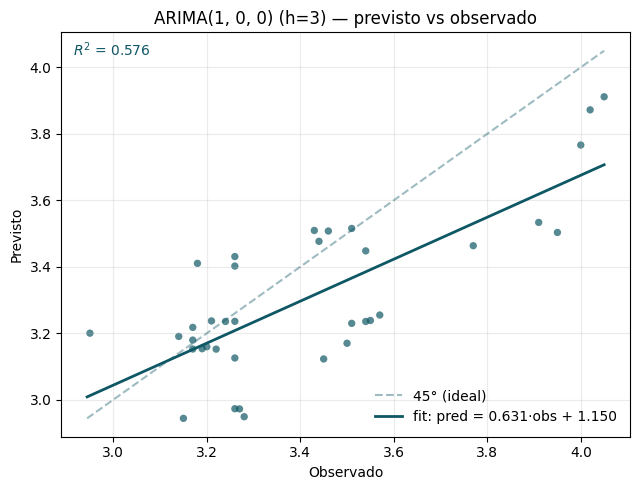

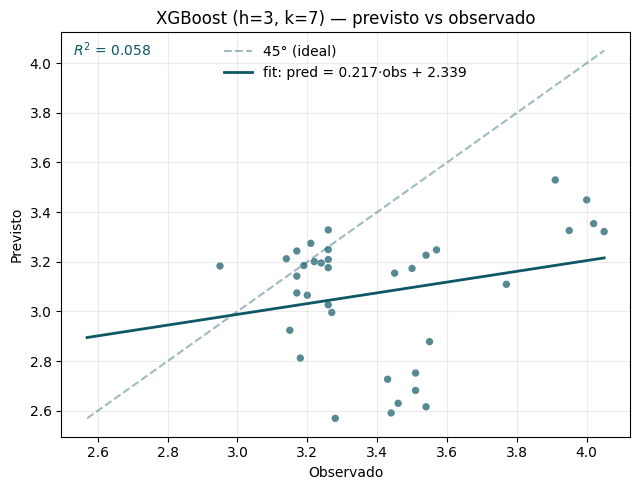

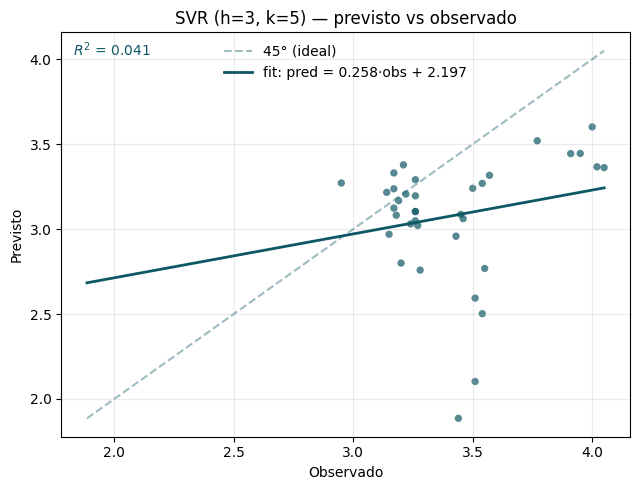

In [12]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

COLOR = "#0e5764"

def plot_regressao(y_true, y_pred, titulo):
    df = pd.concat([y_true.rename("obs"), y_pred.rename("pred")], axis=1).dropna()
    x  = df["obs"].values.reshape(-1, 1)
    lr = LinearRegression().fit(x, df["pred"].values)
    r2 = lr.score(x, df["pred"].values)
    slope, intercept = float(lr.coef_[0]), float(lr.intercept_)
    xy_min = float(min(df.min()))
    xy_max = float(max(df.max()))
    xx = np.linspace(xy_min, xy_max, 100)

    plt.figure(figsize=(6.5, 5))
    plt.scatter(df["obs"], df["pred"], s=28, alpha=0.7, edgecolors="none", color=COLOR)
    plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", lw=1.5, alpha=0.4, color=COLOR, label="45° (ideal)")
    plt.plot(xx, slope * xx + intercept, lw=2.0, color=COLOR,
             label=f"fit: pred = {slope:.3f}·obs + {intercept:.3f}")
    plt.title(titulo)
    plt.xlabel("Observado"); plt.ylabel("Previsto")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)
    plt.text(0.02, 0.98, f"$R^2$ = {r2:.3f}", transform=plt.gca().transAxes,
             ha="left", va="top", fontsize=10, color=COLOR)
    plt.tight_layout()
    plt.show()

plot_regressao(y_true_h3,    yhat_h3,    f"ARIMA{ordem_h3} (h=3) — previsto vs observado")
plot_regressao(y_true_h3_xgb, yhat_xgb_h3, f"XGBoost (h=3, k={melhor_k_xgb}) — previsto vs observado")
plot_regressao(y_true_h3_svr, yhat_svr_h3, f"SVR (h=3, k={melhor_k_svr}) — previsto vs observado")